In [2]:
!conda install -y -c conda-forge xgboost

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\kaihu\anaconda3

  added / updated specs:
    - xgboost


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _py-xgboost-mutex-2.0      |            gpu_0          14 KB  conda-forge
    cuda-version-12.9          |       h4f385c5_3          21 KB  conda-forge
    libxgboost-2.1.3           |cuda126_hb61963e_1        80.8 MB  conda-forge
    openssl-3.6.1              |       hf411b9b_1         8.9 MB  conda-forge
    py-xgboost-2.1.3           |cuda126_pyh3ef1b53_1         132 KB  conda-forge
    xgboost-2.1.3              |cuda126_pyh68bd8d9_1          15 KB  conda-forge
    ------------------------------------------------------------
                                           



==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [3]:
from pathlib import Path
csv_path = Path("C:/Users/kaihu/Downloads/HW2_data.csv")
print("File exists:", csv_path.exists())

File exists: True


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv(csv_path)

In [6]:
y = df["Cell Type"]                 # label first column from dataset
X = df.drop(columns=["Cell Type"])  # all other columns are features

In [7]:
le = LabelEncoder()
y = le.fit_transform(y)  
print("\nLabel mapping:")
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} -> {idx}")


Label mapping:
  B -> 0
  CD14 Monocytes -> 1


In [9]:
#Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=1210,
    stratify=y 
)

In [10]:
gene_names = X_train.columns

In [11]:
#XGBoost (binary classification)
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=1210,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")

XGBoost Test Accuracy: 1.0000


In [13]:
# MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=1210
)

mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, mlp_pred)
print(f"MLP     Test Accuracy: {mlp_acc:.4f}")

MLP     Test Accuracy: 0.9593


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Top-30 genes for XGBoost
xgb_importance = xgb.feature_importances_
xgb_top_idx = np.argsort(xgb_importance)[-30:][::-1]
xgb_top_genes = gene_names[xgb_top_idx]

print(list(xgb_top_genes))

['S100A6', 'S100A8', 'FCGR1A', 'FCN1', 'AIF1', 'EAF2', 'METTL21A', 'C1orf162', 'CDA', 'FCGR2A', 'FGL2', 'CD72', 'LTB', 'FCER1G', 'HLA-DQA1', 'HLA-DPB1', 'CEPT1', 'S100A11', 'SMIM14', 'CXCL8', 'HLA-DQB1', 'GNLY', 'LST1', 'TSPAN33', 'MRPS18A', 'ABHD5', 'PPT1', 'ZNF92', 'IGFBP7', 'CAPZB']


In [16]:
# Top-30 genes for MLP 
mlp_w = mlp.coefs_[0]
mlp_importance = np.mean(np.abs(mlp_w), axis=1)
mlp_top_idx = np.argsort(mlp_importance)[-30:][::-1]
mlp_top_genes = gene_names[mlp_top_idx]

print(list(mlp_top_genes))

['GIMAP2', 'SYP', 'CAVIN2', 'TBCK', 'PIRAT1', 'JCHAIN', 'ACADM', 'ARHGAP19', 'FAM151B-DT', 'SERPINE2', 'MKLN1', 'PHACTR4', 'None.13', 'None.25', 'RNF7', 'SNX14', 'SSBP3', 'TNFSF10', 'PTCRA', 'MTERF4', 'MZB1', 'RBM48', 'FCRL2', 'CHIC2', 'MPP1', 'GSTO1', 'GIMAP5', 'LY6G5B', 'S100A12', 'VDAC3']


In [17]:
#test data for heatmaps
order = np.argsort(y_test)
y_test_sorted = np.array(y_test)[order]

X_test_df = X_test.iloc[order].copy()
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=gene_names).iloc[order].copy()

In [18]:
#count how many cells per type 
unique, counts = np.unique(y_test_sorted, return_counts=True)
split_index = counts[0]   

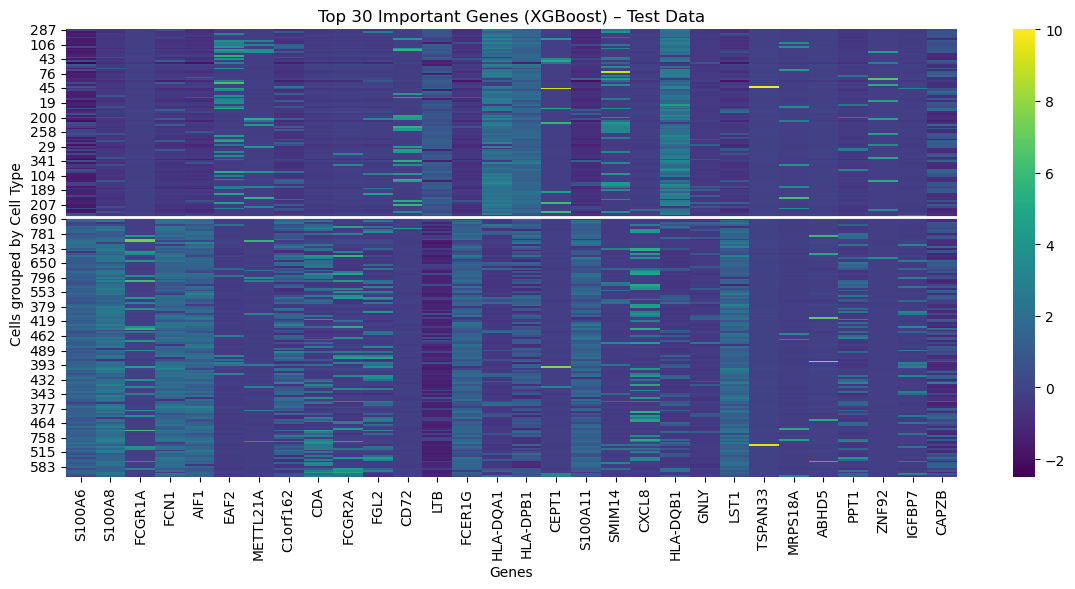

In [19]:
# XGBoost Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(X_test_df[xgb_top_genes], cmap="viridis", cbar=True)

# draw separator line between cell types
plt.axhline(split_index, color="white", linewidth=2)

plt.title("Top 30 Important Genes (XGBoost) – Test Data")
plt.xlabel("Genes")
plt.ylabel("Cells grouped by Cell Type")
plt.tight_layout()
plt.show()

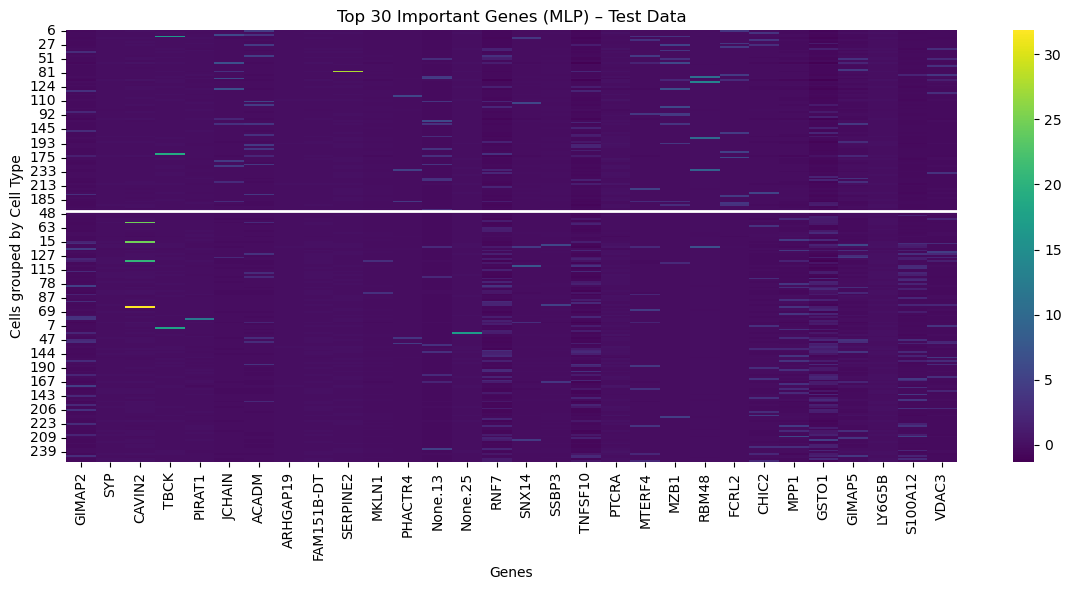

In [20]:
# MLP Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(X_test_scaled_df[mlp_top_genes], cmap="viridis", cbar=True)
plt.axhline(split_index, color="white", linewidth=2)

plt.title("Top 30 Important Genes (MLP) – Test Data")
plt.xlabel("Genes")
plt.ylabel("Cells grouped by Cell Type")
plt.tight_layout()
plt.show()